In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem import rdDistGeom
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdPartialCharges
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from PIL import Image

In [2]:
import os
from glob import glob
import numpy as np
from PIL import Image
import sys
import shutil

In [3]:
from rdkit.Chem.Draw import SimilarityMaps

In [4]:
os.getcwd()

'/home/linu/anaconda3/envs/embedding/rafe_naijian'

In [5]:
df1 = pd.read_excel('./test_data.xlsx')
df1.loc[:, 'IDO1'] = (np.log10((df1.loc[:, 'IDO1'])*10**(-6)))*(-1)
df1.loc[:, 'TDO2'] = (np.log10((df1.loc[:, 'TDO2'])*10**(-6)))*(-1)
df1

/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,cmpd_code,IDO1,TDO2,smiles
0,1a,5.000000,5.000000,O=S(C(N1)=CC2=C1C=CC=C2)CC3=CC=C(C(F)(F)F)C=C3
1,1b,5.000000,5.000000,O=S(C1=CC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3
2,1c,5.000000,5.000000,O=S(C1=NC2=CC=CC=C2N1)CC3=CC=C(C(F)(F)F)C=C3
3,1d,5.552842,5.000000,O=S(C1=NC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3
4,1e,5.040959,5.075721,O=S(C1=NC2=CC=C(Cl)C=C2O1)CC3=CC=CC=C3C(F)(F)F
...,...,...,...,...
106,43a,5.906578,6.698970,CS(=O)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC)C=C3)C...
107,43b,6.508638,7.096910,O=S(C(F)(F)F)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC...
108,43c,5.342944,5.473661,O=S(C1CC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC)C=...
109,43d,4.813326,5.098542,O=S(N1CCCCC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC...


In [6]:
df1.isna().sum()

cmpd_code    0
IDO1         0
TDO2         0
smiles       0
dtype: int64

In [7]:
np.log10(121*10**(-9))

-6.91721462968355

In [8]:
column_mapping = {
    'cmpd_code': 'CHEMBLID',
    'IDO1': 'ido_ic50',
    'TDO2': 'tdo_ic50',
    'smiles': 'smiles'
}

In [9]:
df1 = df1.rename(columns=column_mapping)
df1 = df1[['CHEMBLID', 'smiles', 'ido_ic50', 'tdo_ic50']]
df1

,CHEMBLID,smiles,ido_ic50,tdo_ic50
0,1a,O=S(C(N1)=CC2=C1C=CC=C2)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
1,1b,O=S(C1=CC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
2,1c,O=S(C1=NC2=CC=CC=C2N1)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
3,1d,O=S(C1=NC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3,5.552842,5.000000
4,1e,O=S(C1=NC2=CC=C(Cl)C=C2O1)CC3=CC=CC=C3C(F)(F)F,5.040959,5.075721
...,...,...,...,...
106,43a,CS(=O)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC)C=C3)C...,5.906578,6.698970
107,43b,O=S(C(F)(F)F)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC...,6.508638,7.096910
108,43c,O=S(C1CC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC)C=...,5.342944,5.473661
109,43d,O=S(N1CCCCC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC...,4.813326,5.098542


In [10]:
df1.to_csv("test_data.csv", index=False)

In [11]:
pd.read_csv("test_data.csv")

,CHEMBLID,smiles,ido_ic50,tdo_ic50
0,1a,O=S(C(N1)=CC2=C1C=CC=C2)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
1,1b,O=S(C1=CC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
2,1c,O=S(C1=NC2=CC=CC=C2N1)CC3=CC=C(C(F)(F)F)C=C3,5.000000,5.000000
3,1d,O=S(C1=NC2=CC=CC=C2O1)CC3=CC=C(C(F)(F)F)C=C3,5.552842,5.000000
4,1e,O=S(C1=NC2=CC=C(Cl)C=C2O1)CC3=CC=CC=C3C(F)(F)F,5.040959,5.075721
...,...,...,...,...
106,43a,CS(=O)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC)C=C3)C...,5.906578,6.698970
107,43b,O=S(C(F)(F)F)(NC1=CC=C(C2=CC3=C(C=N2)C(O)=C(OC...,6.508638,7.096910
108,43c,O=S(C1CC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC)C=...,5.342944,5.473661
109,43d,O=S(N1CCCCC1)(NC2=CC=C(C3=CC4=C(C=N3)C(O)=C(OC...,4.813326,5.098542


In [12]:
df2 = df1.loc[:, ['ido_ic50', 'tdo_ic50']]
df2

,ido_ic50,tdo_ic50
0,5.000000,5.000000
1,5.000000,5.000000
2,5.000000,5.000000
3,5.552842,5.000000
4,5.040959,5.075721
...,...,...
106,5.906578,6.698970
107,6.508638,7.096910
108,5.342944,5.473661
109,4.813326,5.098542


In [13]:
n = 0
for i in range(len(df1)):
    if df1['ido_ic50'].values[i] >= 6.15:
        n += 1
print(n)

29


In [14]:
n = 0
for i in range(len(df1)):
    if df1['tdo_ic50'].values[i] >= 6:
        n += 1
print(n)

10


In [15]:
for i in range(len(df2)):
    if df2['ido_ic50'].values[i] >= 6.15:
        df2.loc[i, ['ido_ic50']] = 1
    else:
        df2.loc[i, ['ido_ic50']] = 0

In [16]:
for i in range(len(df2)):
    if df2['tdo_ic50'].values[i] >= 6.0:
        df2.loc[i, ['tdo_ic50']] = 1
    else:
        df2.loc[i, ['tdo_ic50']] = 0

In [17]:
df2

,ido_ic50,tdo_ic50
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
106,0.0,1.0
107,1.0,1.0
108,0.0,0.0
109,0.0,0.0


In [18]:
newcol = []
for i in range(len(df2)):
    if df2['ido_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('AA')
    elif df2['ido_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('II')
    elif df2['ido_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('IA')
    else:
        newcol.append('AI')

In [19]:
target = pd.DataFrame(data=newcol, columns=['ido_tdo'])
target

,ido_tdo
0,II
1,II
2,II
3,II
4,II
...,...
106,IA
107,AA
108,II
109,II


In [20]:
target.to_csv('testdata_target.csv', index=False)

<Axes: xlabel='ido_tdo', ylabel='Count'>

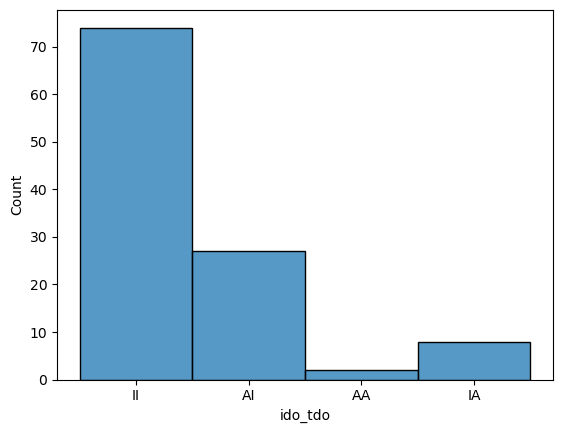

In [21]:
sns.histplot(data=target['ido_tdo'])

In [26]:
target.describe()

,ido_tdo
count,111
unique,4
top,II
freq,74


In [31]:
y = target.values.reshape(len(df2),)
y.shape

(111,)

In [32]:
encoder = LabelEncoder()

In [33]:
y_label = encoder.fit_transform(y)

In [34]:
y_label

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1, 3, 3, 3,
       3, 3, 3, 3, 3, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1,
       3, 1, 1, 1, 1, 1, 0, 1, 3, 3, 3, 3, 1, 1, 1, 1, 3, 1, 3, 3, 1, 1,
       3, 1, 1, 3, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 2, 3, 3, 2, 0, 3, 3,
       3])

In [35]:
from rdkit.Chem import SaltRemover as sr
#remover = sr.SaltRemover(defnData="[Cl,Br,Na,Ca,Mg]")
remover = sr.SaltRemover()

In [36]:
mols = []
for i in range(len(df1)):
    mol_i = Chem.MolFromSmiles(df1['smiles'][i])
    if mol_i is None:
        print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
        mols.append(None)  # Maintain indexing for multiprocessing
        continue
    mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
    mols.append(mol_i)
len(mols)

111